# 01 - Profiling the client's intake systems

**Question this notebook answers:** before writing any rule, what do the five intake channels and the recruiter's
tracker actually contain, and what does that mean for de-duplication?

Everything here reads the *raw* client systems through the same extract functions the pipeline uses.
The findings shape the rules in `docs/validation_rules.md` and the matching rule in `docs/data_model.md`.

> All client data is simulated (see `docs/simulation.md`).

In [1]:
import sys, json, logging, shutil
from datetime import date
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import pandas as pd
import matplotlib.pyplot as plt
from pipeline.config import load_config, ROOT
from pipeline import extract as ex
from pipeline.normalize import normalize_email, normalize_phone, normalize_name, parse_sheet_date
from pipeline.validate import standardize_applications, standardize_tracker
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 20)
cfg = load_config(); log = logging.getLogger("nb"); AS_OF = date(2026, 8, 31)
tmp = Path("/tmp/profiling_raw"); shutil.rmtree(tmp, ignore_errors=True)
store = ex.RawStore(tmp, AS_OF.isoformat(), "profiling")

## 1. Retrieve every source (the job-board API needs the simulated server running)

In [2]:
import subprocess, time, requests
api = None
try:
    requests.get(cfg["sources"]["job_board_api"]["base_url"] + "/health", timeout=1)
except requests.RequestException:
    api = subprocess.Popen([sys.executable, str(ROOT / "client_systems/job_board_api/mock_job_board_api.py")],
                           stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL); time.sleep(1.5)
res = {name: fn(cfg, AS_OF, store, log) for name, fn in ex.EXTRACTORS.items()}
if api: api.terminate()
pd.DataFrame([{"source": k, "rows": len(v.rows), "evidence": v.evidence} for k, v in res.items()])

[extract] job_board_api page=3 | HTTP 500 | attempt=1/4 | retry in 1s


[extract] job_board_api page=5 | HTTP 429 | attempt=1/4 | retry in 1s


[extract] job_board_api: 1 record(s) repeated across pages (offset drift) - kept once


,source,rows,evidence
0,job_board_api,1133,"{'pages': 12, 'records_received': 1134, 'overl..."
1,careers_db,562,"{'query_count': 562, 'rows_returned': 562, 'db..."
2,referral_form,350,"{'file_rows': 350, 'unparseable_timestamps': 0..."
3,whatsapp_export,506,"{'messages_parsed': 1295, 'unparsed_lines': 0,..."
4,ops_head_mailbox,287,"{'messages_in_file': 427, 'parse_failures': 0,..."
5,recruiter_tracker,2548,"{'rows': 2548, 'sha256': '61feb63eea11f3a3', '..."


## 2. Which identifiers does each channel carry?

If one identifier were present everywhere, de-duplication would be a simple join. It isn't.

In [3]:
frames = [res[n].rows for n in ("job_board_api", "careers_db", "referral_form", "whatsapp_export", "ops_head_mailbox")]
apps = standardize_applications(frames, cfg, AS_OF)
cov = apps.groupby("source").agg(applications=("application_id", "count"),
                                  has_email=("email_norm", lambda s: round(100 * s.notna().mean())),
                                  has_phone=("phone_norm", lambda s: round(100 * s.notna().mean())),
                                  has_name=("first_name", lambda s: round(100 * s.notna().mean())))
cov

,applications,has_email,has_phone,has_name
source,,,,
careers,562,100,98,100
email,287,100,39,75
job_board,1133,100,68,100
referral,350,40,87,100
whatsapp,506,10,100,60


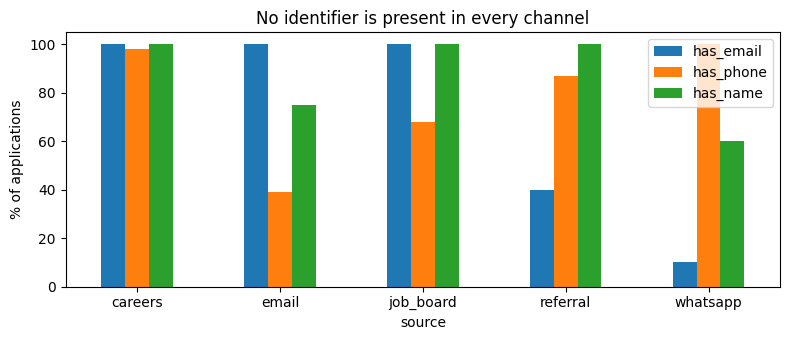

In [4]:
cov[["has_email", "has_phone", "has_name"]].plot(kind="bar", rot=0, figsize=(8, 3.5))
plt.ylabel("% of applications"); plt.title("No identifier is present in every channel"); plt.ylim(0, 105); plt.tight_layout(); plt.show()

**Finding:** WhatsApp has a phone but almost never an email; email applications have an email but usually no phone;
referral forms often lack the candidate's email. **No single key exists across channels**, so matching has to use
email *or* phone - which is exactly where the risks below come from.

## 3. The same identifier is written many ways (representation, safe to normalise)

In [5]:
raw = pd.concat(frames)
examples = raw.dropna(subset=["phone_raw"]).assign(norm=lambda d: d["phone_raw"].map(normalize_phone))
examples = examples.dropna(subset=["norm"])
multi = examples.groupby("norm")["phone_raw"].nunique().sort_values(ascending=False).head(3).index
examples[examples["norm"].isin(multi)][["source", "phone_raw", "norm"]].drop_duplicates().sort_values("norm")

,source,phone_raw,norm
1052,job_board,+91-6643595387,6643595387
139,careers,6643595387,6643595387
275,careers,06643595387,6643595387
417,careers,664 359 5387,6643595387
28,whatsapp,+91 66435 95387,6643595387
271,careers,7036802633,7036802633
389,careers,07036802633,7036802633
96,referral,703 680 2633,7036802633
65,whatsapp,+91 70368 02633,7036802633
272,job_board,+917316640776,7316640776


In [6]:
pd.DataFrame({"raw name": ["Sharma, Rahul", "RAHUL SHARMA", "Rahul S", "rahul sharma", "Rahul"]}).assign(
    parsed=lambda d: d["raw name"].map(normalize_name))

,raw name,parsed
0,"Sharma, Rahul","(rahul, sharma)"
1,RAHUL SHARMA,"(rahul, sharma)"
2,Rahul S,"(rahul, s)"
3,rahul sharma,"(rahul, sharma)"
4,Rahul,"(rahul, None)"


## 4. Common names collide (why name matching over-counts)

A name is not an identifier. How many *distinct email addresses* sit behind the most common full names?

In [7]:
named = apps.dropna(subset=["first_name", "last_name", "email_norm"])
collide = (named.assign(full=named["first_name"] + " " + named["last_name"])
                .groupby("full")["email_norm"].nunique().sort_values(ascending=False).head(8))
collide.rename("distinct email addresses").to_frame()

,distinct email addresses
full,
rahul kumar,15
neha kumar,13
priya singh,11
amit singh,10
rahul sharma,9
rohit singh,9
priya patel,9
priya kumar,8


**Finding:** the most common names are shared by many different people, so "same name = same person" merges
strangers. That is why the old name-matched baseline is an **over**-count, not the lower bound Assignment 1 assumed.

## 5. Identifiers that must never be used for matching

In [8]:
ph = apps.dropna(subset=["phone_norm"])
print("Applications whose phone is a placeholder or hub value (A06, removed from matching):", int(apps["warning_reasons"].str.contains("A06").sum()))
shared = ph.dropna(subset=["first_name"]).groupby("phone_norm")["first_name"].nunique()
print("Phones used by 2+ different first names (siblings / shared phones):", int((shared >= 2).sum()))
print("Referral rows where the candidate phone is the referrer's own:", int(apps["warning_reasons"].str.contains("A07").sum()))
apps[apps["warning_reasons"].str.contains("A06|A07")][["source", "name_raw", "phone_raw", "warning_reasons"]].head(8)

Applications whose phone is a placeholder or hub value (A06, removed from matching): 7
Phones used by 2+ different first names (siblings / shared phones): 37
Referral rows where the candidate phone is the referrer's own: 23


,source,name_raw,phone_raw,warning_reasons
166,referral,Payal Jain,6572601570,A04;A07;A03
181,careers,Priya Patel,9999999999,A06
184,referral,Rahul J,9059646295,A07;A03
236,referral,Geeta Sharma,7491896927,A04;A07;A03
299,referral,Bhavna Fernandes,9396684717,A07
429,referral,Tarun,9286213748,A04;A07;A03
466,referral,Joseph,9852286869,A04;A07;A03
1006,referral,Naveen Nair,6949620702,A07;A03


## 6. The recruiter's tracker: hand-typed dates and free-text statuses

In [9]:
tr_raw = res["recruiter_tracker"].rows
methods = tr_raw["Date Logged"].map(lambda s: parse_sheet_date(s)[1]).value_counts()
methods.rename("rows").to_frame()

,rows
Date Logged,
iso,1707
day_first,469
day_first_ambiguous,268
day_month_abbrev,104


In [10]:
tr_raw["Status"].value_counts().rename("rows").to_frame()

,rows
Status,
Not suitable,322
Rejected,315
Rejected,291
NS,289
rejected,281
dup,159
Duplicate,157
DUP,142
Phone screen done,79


**Finding:** 'NS' and 'On hold' have no agreed meaning ('not suitable'? 'no show'?) so they are flagged, not mapped.
A row counts as screened only when **Screened On** has a date - the label is not trusted to say what happened.
About 10% of logged dates are day/month ambiguous (e.g. 03/08/2026); they are read day-first, the sheet's convention.

## 7. Does every application reach the tracker?

In [11]:
from pipeline.resolve import link_tracker
tr = link_tracker(standardize_tracker(tr_raw, AS_OF), apps, cfg)
linked = set(tr["application_id"].dropna())
reach = apps.assign(in_tracker=apps["application_id"].isin(linked)).groupby("source")["in_tracker"].mean().mul(100).round(1)
reach.rename("% of applications that reached the tracker").to_frame()

,% of applications that reached the tracker
source,
careers,100.0
email,67.6
job_board,100.0
referral,70.0
whatsapp,69.8


**Finding:** the auto-exported channels (job boards, careers page) all reach the tracker; the manually forwarded ones
(referrals, WhatsApp, email to the Ops head) lose about 30% (only 68–70% reach the tracker). Those candidates are invisible to the recruiter -
the 'unreviewed' figure the client believes (about 15%) cannot include them.

## What profiling changed
| Finding | Rule / decision it produced |
|---|---|
| No identifier in every channel | Match on email **or** phone (not a single key) |
| Phone formats differ | Normalise to 10 digits (representation) |
| Common names collide | Name alone never merges; name only **confirms** a phone match |
| Siblings share phones, referrers type their own | A06 hub detection, A07, and phone matches require compatible names |
| Placeholder numbers | A06: excluded from matching |
| Ambiguous statuses | T06: flagged; screens counted from the date, not the label |
| Manual channels leak | M2a: 'never reached the tracker' reported separately |
